# AI Disclaimer
AI was used extensively to write the code for this assignment. The flow and logic are mine. I also used AI as a proofreader and editor to ensure that I met all assignment requirements.

AI stack:
Hermes agentic framework (with custom skills)
Codex 5.5 LLM

# Assignment 4.1 — Match Outcome Prediction

## Overview

You are given a feature-engineered dataset of League of Legends ranked games collected via the Riot API. Your task is to build the best pre-game match outcome predictor you can, evaluated on a held-out test set.

The target variable is `bwin` — 1 if the blue team won, 0 if red won.

---

## Data

Load the parquet file provided on the course repository:

```python
import pandas as pd
from huggingface_hub import HfApi
api = HfApi()
files = api.list_repo_files(
    repo_id="rubiogarciaf/games_20260608",
    repo_type="dataset"
)
parquet_files = [f for f in files if f.endswith(".parquet")]

base = "https://huggingface.co/datasets/rubiogarciaf/games_20260608/resolve/main"
df = pd.concat(
    [pd.read_parquet(f"{base}/{f}") for f in parquet_files],
    ignore_index=True
)
df['gameId'] = df['gameId'].astype(str)
df.head(5)
```

The dataset covers **patches 1610 and 1611**, with games played between **May 13, 2026 and June 6, 2026**.

---

## Requirements

### Train/Test Split

You must use the following split — no exceptions:

- **Training set:** all games where `gameCreation` is at or below the 80th percentile of `gameCreation`
- **Test set:** all remaining games (the top 20%)

```python
cutoffs = df.groupby('patch')['gameCreation'].quantile(0.8)
df['cutoff'] = df['patch'].map(cutoffs)

train = df[df['gameCreation'] <= df['cutoff']]
test  = df[df['gameCreation'] >  df['cutoff']]
```

You must evaluate on **all games in the test set**. Do not filter or drop test rows.

You may use patch 1610 data however you like within training — as additional training rows, for feature construction, or not at all. Justify your choice.

### Metrics

Report all three on the test set:

| Metric | Function |
|---|---|
| AUC | `roc_auc_score(y_test, proba)` |
| Brier Score | `brier_score_loss(y_test, proba)` |
| Accuracy | `accuracy_score(y_test, preds)` |

AUC is the primary metric. Your model must produce probability estimates, not just class labels.

---

## What's Already in the Dataset

The parquet contains pre-built features for each game. All features are available
as both **per-slot columns** (e.g. `b1_bayesian_wr_champ`) and **team difference
columns** (e.g. `diff_bayesian_wr_champ`).

### Champion Features
- `*_bayesian_wr_champ` — champion win rate regardless of position
- `*_bayesian_wr_champ_pos` — champion win rate in the specific role played
- `*_bayesian_wr_tier_champ` — champion win rate within the game's tier bracket
- `*_bayesian_wr_tier_champ_pos` — champion win rate by role and tier

### Player Features
- `*_bayesian_wr_puuid` — player's overall win rate
- `*_bayesian_wr_puuid_pos` — player's win rate in this role
- `*_bayesian_wr_puuid_champ_pos` — player's win rate on this champion in this role
- `*_bayesian_wr_tier_puuid` — player win rate within their tier bracket
- `*_bayesian_wr_tier_puuid_pos` — player win rate by role and tier
- `*_bayesian_wr_tier_puuid_champ_pos` — player win rate on this champion in this role and tier

### Team Interaction Features
- `diff_bayesian_wr_synergy` — team synergy advantage (champion pair win rates)
- `diff_bayesian_wr_counter` — team counter advantage (cross-team matchup win rates)
- `diff_bayesian_wr_tier_synergy` — synergy within tier bracket
- `diff_bayesian_wr_tier_counter` — counter advantage within tier bracket

### Player Trajectory Features
- `*_lp_median_7d` — median league points over player's last 7 active days
- `*_lp_slope_7d` — OLS slope of LP over last 7 active days (positive = climbing)
- `*_leaguePoints` — player's LP as of the previous day
- `*_mastery_points` — champion mastery points as of the previous day

All features respect the `available_on` constraint — only information available
before the game started is used.
---

## Ideas for Improvement

You are encouraged to experiment. Some directions worth exploring:

**Feature selection**  
Many columns are highly correlated with each other. Use correlation analysis to identify and remove redundant features before fitting. A leaner feature set often generalizes better than a wide one.

**Null handling**  
Some players have no history in the dataset window. Think carefully about what value to impute for missing Bayesian win rates — filling with 0 is not the same as filling with the prior (0.5), and the choice affects your diff columns.

**Scaling**  
Logistic regression is sensitive to feature scale. LP values are in the thousands; Bayesian win rate differences are in the range ±0.1. StandardScaler fixes this and can meaningfully improve convergence.

**Categorical variables**  
Champion IDs and tier are available. If you use them, think carefully about encoding — label encoding imposes an ordinal relationship that doesn't exist for champion IDs. Consider whether a tree-based model handles them more naturally.

**Model choice**  
Logistic regression is a reasonable baseline. LightGBM handles high-cardinality categoricals natively and can capture nonlinear interactions. You are free to try any model, but justify your choice.

---

## Ideas for New Features

The dataset gives you `thin_df` — one row per player per game — which means you can
build any player or champion level statistic and join it back to the game level using
the `available_on` pattern from lecture. Here are some directions worth exploring:

**Champion synergy**  
How much better is a champion when paired with a specific teammate?
For every unordered (championId_A, championId_B) pair on the same team,
compute their cumulative win rate together. A team whose champions historically
synergize well may outperform what individual win rates predict.

**Champion counters**  
How much better or worse does a champion perform against a specific enemy champion?
For every (blue_championId, red_championId) matchup, compute the blue win rate.
A team with favorable matchups across the board has a structural advantage before
the game starts.

**LP trajectory**  
Is this player climbing or falling in rank? A rolling OLS slope over their last 7
days of league points tells you whether they are in form or tilting. A team whose
players are all climbing is meaningfully different from a team that is stagnant.

**Autofill detection**  
Is a player playing their main role? Compare `teamPosition` to their most
frequently played position historically. An autofilled player tends to underperform
relative to their overall win rate.

All new features must respect the `available_on` constraint — you can only use
information that was available before the game started. Same-day statistics leak
the outcome.

## Deliverables

Submit a Jupyter notebook containing:

1. **Data loading and split** — show train/test sizes and confirm you are using the correct split
2. **Feature selection** — document which features you kept and why, supported by correlation analysis or another justification
3. **Model training** — at least one model, clearly documented
4. **Results** — AUC, Brier, and Accuracy on the test set in a summary table
5. **Written reflection** (one paragraph) — what is the biggest limitation of this model? What additional data or features would most improve it, and why?

---

## Reference Baseline

The baseline below are the metrics that I achieved with the attached dataset.

| Metric | Score |
|---|---|
| AUC | 0.5601 |
| Brier | 0.2471 |
| Accuracy | 0.5416 |

You are not required to beat this. You are required to understand why your model performs the way it does.

## Part 1
Why this split, and not a random one? Two reasons specific to this dataset. First, the features are cumulative in time: a champion's Bayesian win rate on June 5 was built from games before June 5. Second, the same players and champions recur across games. A random split scatters games from the same day, the same player, and the same cumulative window across both train and test, so the model effectively learns from the future and from the test rows' own neighbors. The patch-based split mimics what deployment actually looks like. You train on the past and predict matches that have not happened yet. Holding the split fixed is what makes your test number mean something.

In [1]:
import numpy as np


In [2]:
import pandas as pd
from huggingface_hub import HfApi
api = HfApi()
files = api.list_repo_files(
    repo_id="rubiogarciaf/games_20260608",
    repo_type="dataset"
)
parquet_files = [f for f in files if f.endswith(".parquet")]

base = "https://huggingface.co/datasets/rubiogarciaf/games_20260608/resolve/main"
df = pd.concat(
    [pd.read_parquet(f"{base}/{f}") for f in parquet_files],
    ignore_index=True
)
df['gameId'] = df['gameId'].astype(str)
df.head(5)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,gameId,gameCreation,patch,bwin,b1_bayesian_wr_champ,b2_bayesian_wr_champ,b3_bayesian_wr_champ,b4_bayesian_wr_champ,b5_bayesian_wr_champ,r1_bayesian_wr_champ,...,b2_mastery_points,b3_mastery_points,b4_mastery_points,b5_mastery_points,r1_mastery_points,r2_mastery_points,r3_mastery_points,r4_mastery_points,r5_mastery_points,diff_mastery_points
0,5576347036,1780789359000,1611,1,0.522189,0.499140,0.521362,0.508294,0.516447,0.514471,...,NaN,NaN,127061.0,7852.0,NaN,26785.0,25590.0,NaN,NaN,41269.0
1,5576346899,1780789323000,1611,1,0.474966,0.510358,0.510635,0.508294,0.507439,0.481380,...,NaN,NaN,169998.0,NaN,196064.0,NaN,NaN,NaN,430691.0,-143379.5
2,5576346837,1780789323000,1611,1,0.498269,0.501772,0.503663,0.508294,0.497132,0.518291,...,239595.0,NaN,NaN,NaN,233283.0,1844766.0,NaN,NaN,NaN,-799429.5
3,5576346425,1780789452000,1611,0,0.503022,0.497654,0.492653,0.507657,0.520145,0.481380,...,220332.0,368556.0,NaN,NaN,NaN,NaN,NaN,NaN,1646787.0,-1352343.0
4,5576346261,1780789398000,1611,1,0.468694,0.490393,0.510429,0.459451,0.515964,0.514505,...,NaN,936510.0,NaN,NaN,NaN,6085127.0,NaN,NaN,NaN,-5148617.0


In [3]:
cutoffs = df.groupby('patch')['gameCreation'].quantile(0.8)
df['cutoff'] = df['patch'].map(cutoffs)
train = df[df['gameCreation'] <= df['cutoff']]
test  = df[df['gameCreation'] >  df['cutoff']]
train = train.drop(['cutoff'], axis=1)
test  = test.drop(['cutoff'], axis=1)

In [4]:
print(f"Train data shape: {train.shape}")
print(f"Test data shape: {test.shape}")

Train data shape: (636351, 162)
Test data shape: (159088, 162)


## Part 2: Feature Selection

The parquet ships every feature in two forms: per-slot columns (e.g. b1_bayesian_wr_champ, …, r5_bayesian_wr_champ) and a team-difference column (e.g. diff_bayesian_wr_champ). Decide what to feed the model and document your choices.

Redundancy. Many columns are highly correlated. Run a correlation analysis and remove redundant features. A leaner feature set usually generalizes better than a wide one. Show the evidence behind what you dropped.
Nulls. Some players and champion pairs have no history inside the data window, so some Bayesian win rates are missing. The fill value matters: filling with 0 is not the same as filling with the prior (0.5), and the choice propagates into your diff_ columns. State what you impute and why.
Scaling. Logistic regression is sensitive to feature scale — LP values are in the thousands while Bayesian win-rate differences sit in the range ±0.1. If you use a linear model, StandardScaler will meaningfully improve convergence.

We are trying to predict wins at the team level so I suspect that the best bang for the buck (effort) will be in the team level comparison statistics rather than at the individual slot/player level. Initially I will focus on the diff columns for this reason.

### Redundancy

In [5]:
diff_cols = [c for c in train.columns if c.startswith('diff_')]

corr_df = train[['bwin'] + diff_cols].copy()

corr = corr_df.corr(numeric_only=True)

target_corr = (
    corr['bwin']
    .drop('bwin')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

target_corr

,bwin
diff_bayesian_wr_champ_pos,0.082531
diff_bayesian_wr_champ,0.074032
diff_bayesian_wr_counter,0.071144
diff_bayesian_wr_synergy,0.070089
diff_bayesian_wr_tier_champ_pos,0.048022
diff_bayesian_wr_tier_champ,0.047510
diff_lp_median_7d,0.037658
diff_bayesian_wr_tier_synergy,0.035958
diff_lp_slope_7d,-0.034268
diff_bayesian_wr_tier_counter,0.031454


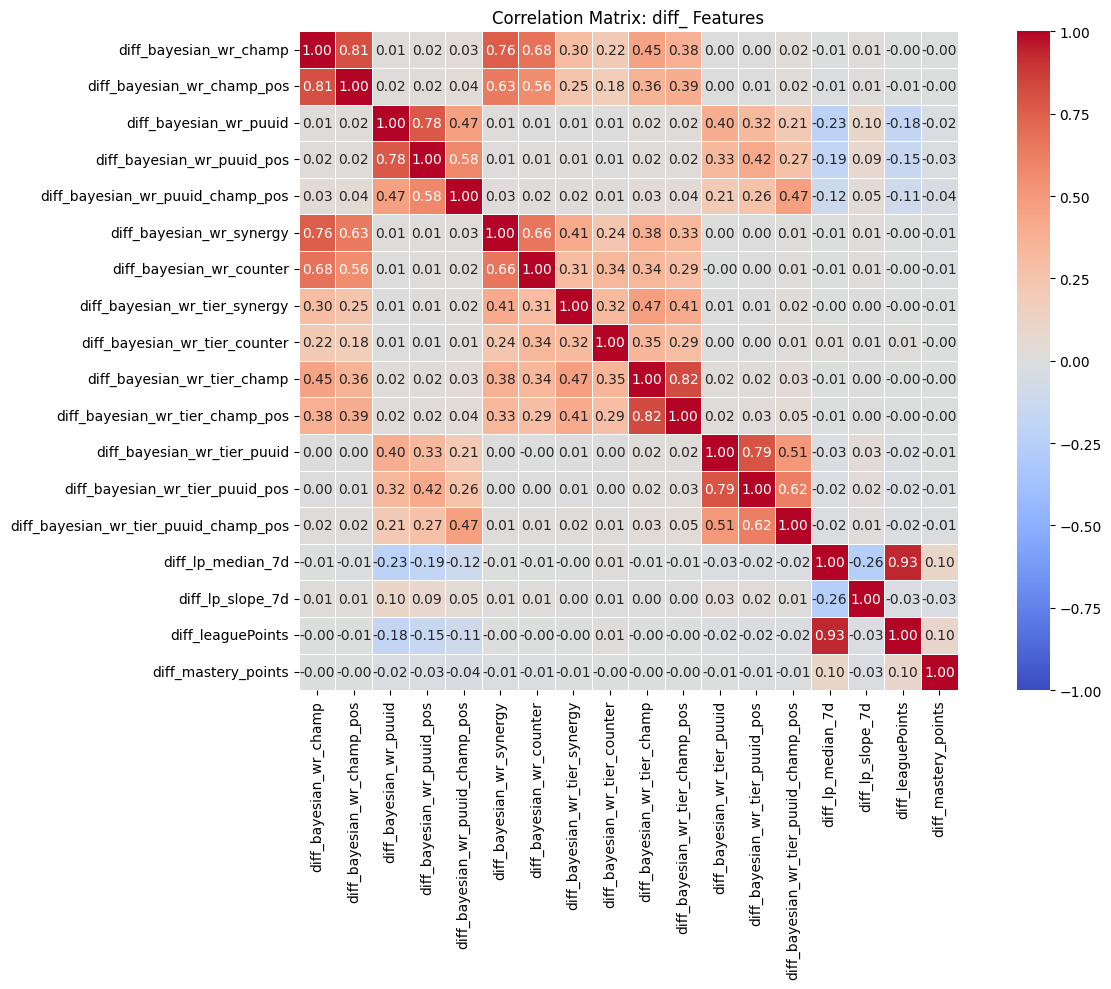

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

diff_cols = [c for c in train.columns if c.startswith('diff_')]

# Correlation among diff features only
diff_corr = train[diff_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    diff_corr,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix: diff_ Features")
plt.tight_layout()
plt.show()

In [7]:
upper = diff_corr.abs().where(
    np.triu(np.ones(diff_corr.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .sort_values(ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.8]
high_corr_pairs

,,0
diff_lp_median_7d,diff_leaguePoints,0.931319
diff_bayesian_wr_tier_champ,diff_bayesian_wr_tier_champ_pos,0.823715
diff_bayesian_wr_champ,diff_bayesian_wr_champ_pos,0.805690


In [8]:
to_drop_cols = []

for (col1, col2), _ in high_corr_pairs.items():
    if abs(target_corr[col1]) < abs(target_corr[col2]):
        to_drop_cols.append(col1)
    else:
        to_drop_cols.append(col2)

print("Columns to drop from highly correlated pairs:")
display(to_drop_cols)

Columns to drop from highly correlated pairs:


['diff_leaguePoints', 'diff_bayesian_wr_tier_champ', 'diff_bayesian_wr_champ']

We have a long list of columns so I went with a correlation of 0.8 as a threshold for finding columns to discard. I took the pairs then identified the one out of the pair that had the lowest correlation with bwin. We'll discard those.

In [9]:
feature_cols = [
    c for c in diff_cols
    if c not in to_drop_cols
]

dropped_evidence = []

for (col1, col2), pair_corr in high_corr_pairs.items():
    drop_col = col1 if abs(target_corr[col1]) < abs(target_corr[col2]) else col2
    keep_col = col2 if drop_col == col1 else col1

    dropped_evidence.append({
        'feature_1': col1,
        'feature_2': col2,
        'abs_pair_corr': pair_corr,
        'feature_1_target_corr': target_corr[col1],
        'feature_2_target_corr': target_corr[col2],
        'dropped': drop_col,
        'kept': keep_col
    })

pd.DataFrame(dropped_evidence)

,feature_1,feature_2,abs_pair_corr,feature_1_target_corr,feature_2_target_corr,dropped,kept
0,diff_lp_median_7d,diff_leaguePoints,0.931319,0.037658,0.028120,diff_leaguePoints,diff_lp_median_7d
1,diff_bayesian_wr_tier_champ,diff_bayesian_wr_tier_champ_pos,0.823715,0.047510,0.048022,diff_bayesian_wr_tier_champ,diff_bayesian_wr_tier_champ_pos
2,diff_bayesian_wr_champ,diff_bayesian_wr_champ_pos,0.805690,0.074032,0.082531,diff_bayesian_wr_champ,diff_bayesian_wr_champ_pos


In [10]:
X_train = train[feature_cols].copy()
X_test  = test[feature_cols].copy()

y_train = train['bwin']
y_test  = test['bwin']

### Nulls
My feature list is all diffs right now. These types of columns are comparisons between blue and red (blue minus red). This means that 0 is neutral. 0.5 would be neutral for probabilities. So I'll fill with zeros. I'm also going to experiment with this concept of a missing indicator as the fact that a value is missing has some predictive potential - it could mean that someone was entirely inexperienced with a given champion or position etc.

In [11]:
missing_cols = [c for c in feature_cols if train[c].isna().any()]

for col in missing_cols:
    X_train[col + '_missing'] = X_train[col].isna().astype(int)
    X_test[col + '_missing'] = X_test[col].isna().astype(int)

X_train[feature_cols] = X_train[feature_cols].fillna(0)
X_test[feature_cols] = X_test[feature_cols].fillna(0)

### Scaling
I built a training pipeline that includes scaling. This normalizes the significant scale differences between the League Point diffs and the bayesian diffs.

## Part 3: Model Training
I used logistic regression as the first pass model because it's interpretable, straightforward with regard to working with our difference type fields, and produces the appropriate output for AUC and Brier score. This aligned with the assignment direction of the engineered features.

I used scaling inside a pipeline before fitting the model. This addresses the magnitude discrepancies between the features and allows us to use the coefficients as a guide for feature impact on the model.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

log_reg_pipe.fit(X_train, y_train)

proba = log_reg_pipe.predict_proba(X_test)[:, 1]
preds = (proba >= 0.5).astype(int)

In [13]:
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score

auc_score = roc_auc_score(y_test, proba)
brier_score = brier_score_loss(y_test, proba)
accuracy = accuracy_score(y_test, preds)

print(f"AUC: {auc_score:.4f}")
print(f"Brier Score: {brier_score:.4f}")
print(f"Accuracy: {accuracy:.4f}")

AUC: 0.5691
Brier Score: 0.2463
Accuracy: 0.5499


## Part 4: Results

### Model metrics

In [14]:
baseline_auc = 0.5601
baseline_brier = 0.2471
baseline_accuracy = 0.5416

results = pd.DataFrame({
    'Metric': ['AUC', 'Brier Score', 'Accuracy'],
    'Function': [
        'roc_auc_score(y_test, proba)',
        'brier_score_loss(y_test, proba)',
        'accuracy_score(y_test, preds)'
    ],
    'Reference Baseline': [baseline_auc, baseline_brier, baseline_accuracy],
    'My Score': [auc_score, brier_score, accuracy]
})

results

,Metric,Function,Reference Baseline,My Score
0,AUC,"roc_auc_score(y_test, proba)",0.5601,0.569115
1,Brier Score,"brier_score_loss(y_test, proba)",0.2471,0.246328
2,Accuracy,"accuracy_score(y_test, preds)",0.5416,0.549935


### Coefficients
For this type of model this can be used as an approximate guide to feature importance.

In [15]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg_pipe.named_steps['model'].coef_[0]
})

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

coef_df

,feature,coefficient,abs_coefficient
0,diff_bayesian_wr_champ_pos,0.103992,0.103992
12,diff_lp_median_7d,0.058936,0.058936
5,diff_bayesian_wr_counter,0.057659,0.057659
3,diff_bayesian_wr_puuid_champ_pos,0.055358,0.055358
13,diff_lp_slope_7d,-0.052485,0.052485
1,diff_bayesian_wr_puuid,-0.045717,0.045717
4,diff_bayesian_wr_synergy,0.025061,0.025061
8,diff_bayesian_wr_tier_champ_pos,0.024056,0.024056
14,diff_mastery_points,0.019893,0.019893
2,diff_bayesian_wr_puuid_pos,0.012447,0.012447


## Part 5: Reflection and Organizational Reasoning

### Mechanical interpretation

With logistic regression applied to a scaled dataset we can use the coefficients as a reasonable proxy for feature importance in the model. One caveat is that closely correlated features can share/steal each other's importance as determined by the coefficients.

Note the strongest coefficient belongs to diff_bayesian_wr_champ_pos indicating a higher strength for the champion-role feature. LP trajectory, counter features, and player-on-champion-position history also received meaningful weights. Pure player-level and tier-player features were weaker. The missingness indicators were not very helpful at all.

My thought is that the generally lower puuid importance is driven by the sparseness of the data for individuals. Since we are breaking the data by patch this will probably persist as two weeks isn't a long time to identify individual performance.

### Organizational reasoning
An AUC around 0.57 means the model is better than random but only modestly so. This suggests that we have a useful model but that there isn't enough signal to strongly determine match outcomes. From a player perspective this is a good thing. The match algorithm works well to balance the opponent teams and most of the outcome is determined by execution during the game.

For my original use case of providing wager assistance I'll use the baseline as a proxy - we're not significantly better than the baseline so we can't expect to have improved on any kind of odds setting by the house or other gamblers. This model would be appropriate to augment human judgement in making decisions generally but does not provide sufficient accuracy for standalone decision rules.

### Split discussion

As discussed in the lecture and assignment, we were provided a temporal split method and given the (prudent) guidance to not change it. The other likely method would be a random split, which would introduce significant data leakage. A random split would disregard the temporal nature of the data - we can't know the future in production, and allow training on data that effectively hasn't happened yet. After training we would then be testing with data randomly selected partially from the past. Our AUC would be inflated because of this leakage from the future.

Because we are given a fixed dataset we have to simulate the future by splitting the data somewhere on the timeline.